In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
palette = sns.color_palette('Set2', 5)
print("✅ Libraries imported")

✅ Libraries imported


In [2]:
df = pd.read_csv('single_genre_artists.csv')
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
df.head()

Shape: 95,837 rows × 23 columns
Missing values: 0
Duplicates: 0


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity_songs,95837.0,26.066394,16.254133,0.00000,13.0000,26.000000,37.0000,9.800000e+01
duration_ms,95837.0,208732.031835,117752.555950,6373.00000,157333.0000,204000.000000,250267.0000,4.800118e+06
explicit,95837.0,0.029644,0.169604,0.00000,0.0000,0.000000,0.0000,1.000000e+00
danceability,95837.0,0.586853,0.155422,0.00000,0.4880,0.605000,0.7000,9.910000e-01
energy,95837.0,0.541083,0.236304,0.00002,0.3650,0.542000,0.7270,1.000000e+00
key,95837.0,5.196782,3.534923,0.00000,2.0000,5.000000,8.0000,1.100000e+01
loudness,95837.0,-10.157862,4.748798,-50.17400,-12.7230,-9.397000,-6.6920,5.376000e+00
mode,95837.0,0.648069,0.477575,0.00000,0.0000,1.000000,1.0000,1.000000e+00
speechiness,95837.0,0.168832,0.275417,0.00000,0.0341,0.046200,0.1030,9.680000e-01
acousticness,95837.0,0.458989,0.330416,0.00000,0.1330,0.453000,0.7590,9.960000e-01


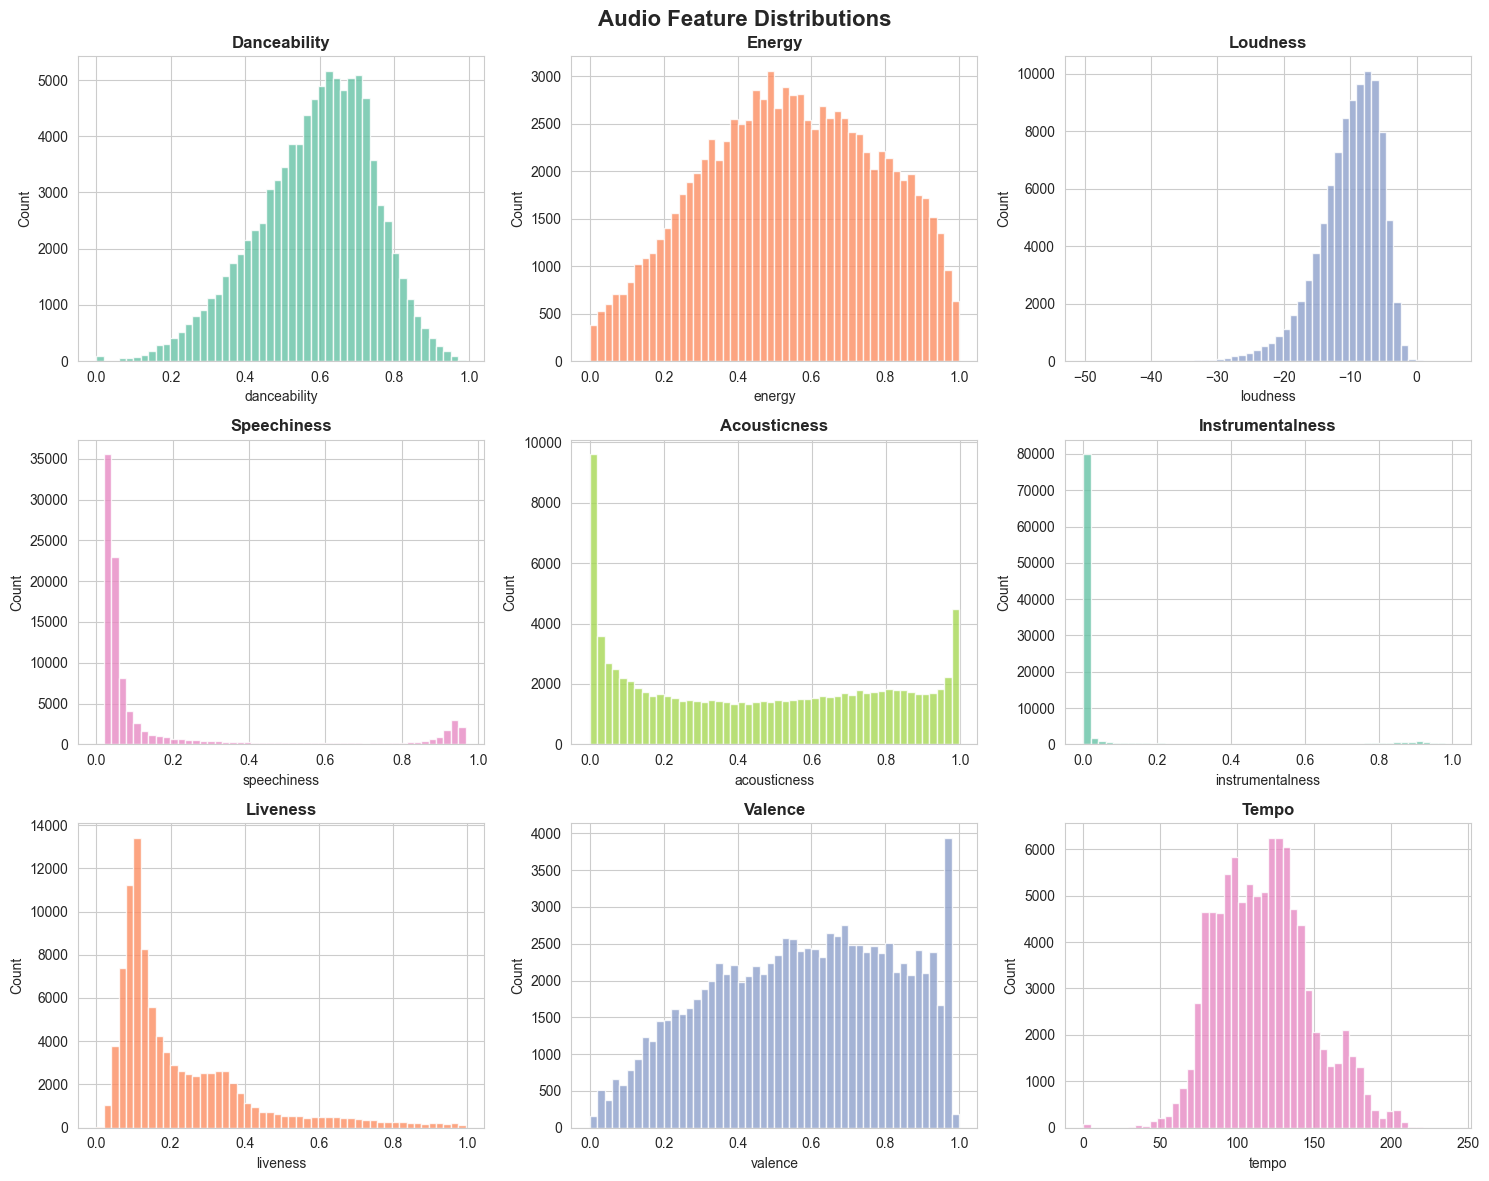

In [4]:
audio_f = ['danceability','energy','loudness','speechiness','acousticness',
           'instrumentalness','liveness','valence','tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
ax = axes.flatten()
for i, feat in enumerate(audio_f):
    ax[i].hist(df[feat], bins=50, color=palette[i % 5], edgecolor='white', alpha=0.8)
    ax[i].set_title(feat.capitalize(), fontweight='bold')
    ax[i].set_xlabel(feat); ax[i].set_ylabel('Count')
plt.suptitle('Audio Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

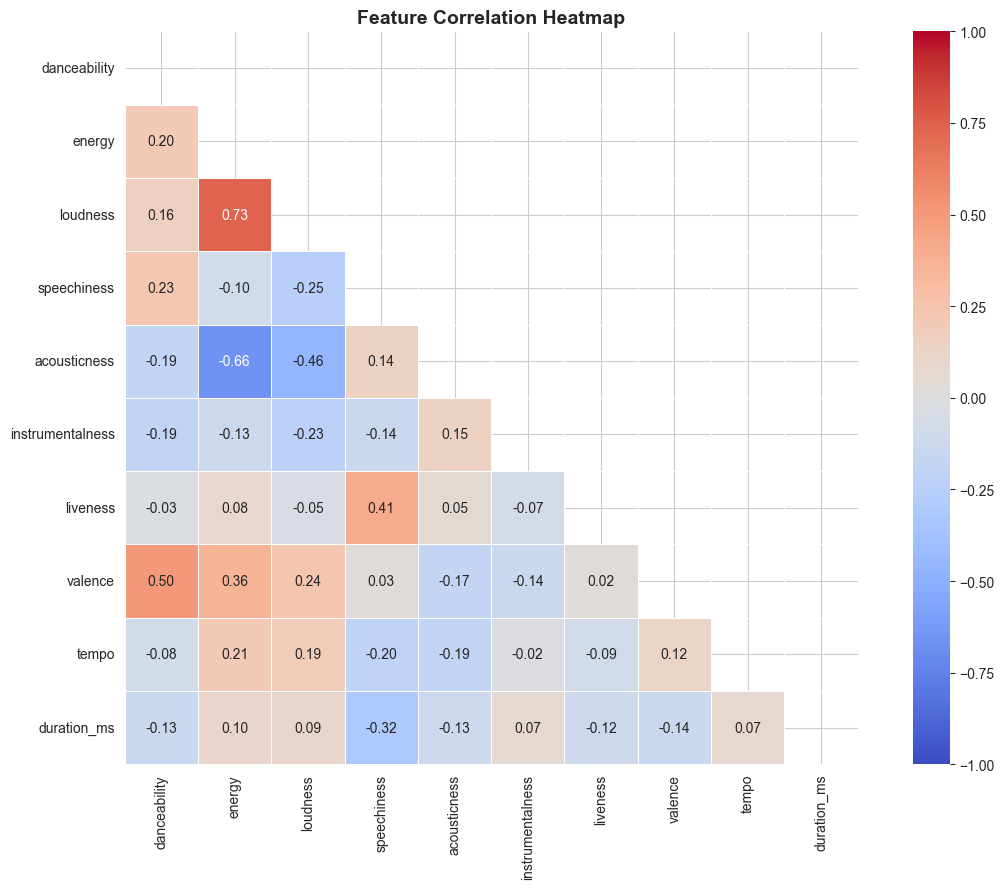

In [5]:
FEATURES = ['danceability','energy','loudness','speechiness','acousticness',
            'instrumentalness','liveness','valence','tempo','duration_ms']

corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])
print(f"Scaled shape: {X_scaled.shape}")
print(f"Mean ≈ {X_scaled.mean():.4f} | Std ≈ {X_scaled.std():.4f}")

Scaled shape: (95837, 10)
Mean ≈ -0.0000 | Std ≈ 1.0000


In [7]:
K_RANGE = range(2, 11)
inertias, sil_scores = [], []

np.random.seed(42)
sidx = np.random.choice(len(X_scaled), 20000, replace=False)
Xs = X_scaled[sidx]

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    s = silhouette_score(Xs, lbl, sample_size=5000, random_state=42)
    sil_scores.append(s)
    print(f"k={k}  inertia={km.inertia_:,.0f}  silhouette={s:.4f}")

k=2  inertia=161,158  silhouette=0.2039
k=3  inertia=136,441  silhouette=0.2435
k=4  inertia=122,247  silhouette=0.2302
k=5  inertia=113,057  silhouette=0.1892
k=6  inertia=107,337  silhouette=0.1622
k=7  inertia=100,673  silhouette=0.1638
k=8  inertia=95,589  silhouette=0.1719
k=9  inertia=91,106  silhouette=0.1679
k=10  inertia=86,142  silhouette=0.1757


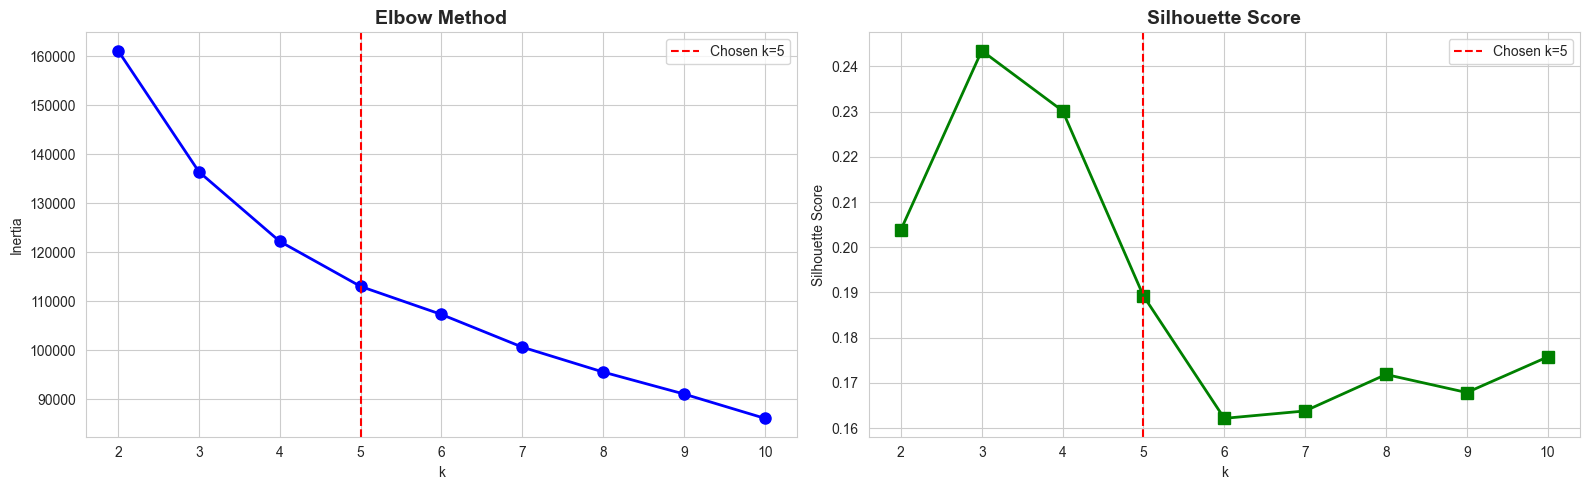

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_RANGE, inertias, 'bo-', lw=2, markersize=8)
axes[0].axvline(5, color='red', ls='--', label='Chosen k=5')
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(K_RANGE, sil_scores, 'gs-', lw=2, markersize=8)
axes[1].axvline(5, color='red', ls='--', label='Chosen k=5')
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].legend()

plt.tight_layout(); plt.show()

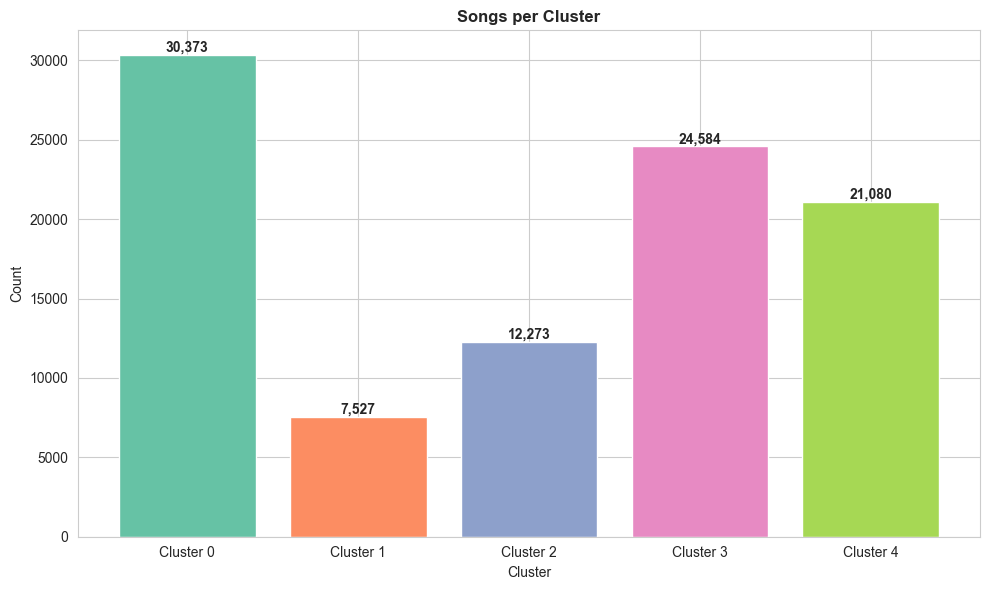

In [9]:
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

cluster_counts = pd.Series(labels).value_counts().sort_index()
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=palette, edgecolor='white')
for bar, cnt in zip(bars, cluster_counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{cnt:,}', ha='center', fontweight='bold')
plt.title('Songs per Cluster', fontweight='bold')
plt.xlabel('Cluster'); plt.ylabel('Count')
plt.xticks(range(5), [f'Cluster {i}' for i in range(5)])
plt.tight_layout(); plt.show()

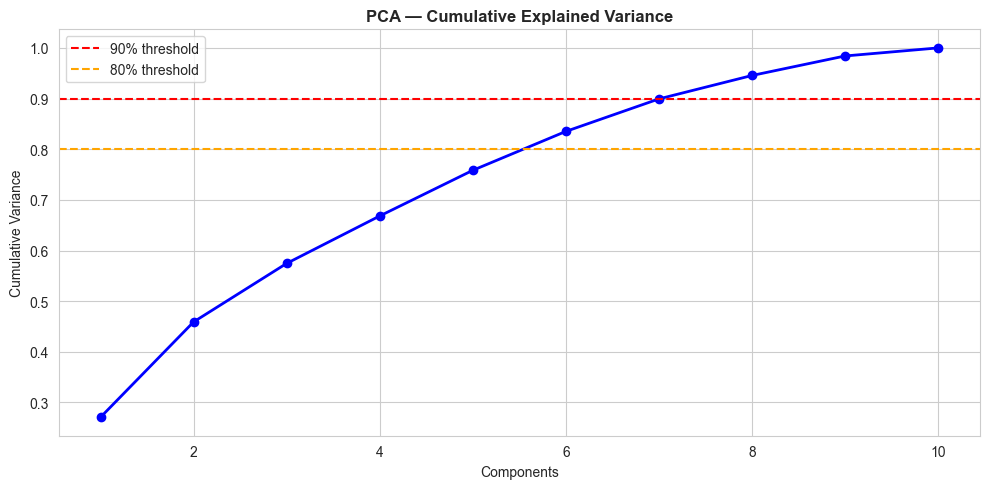

In [10]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, 'bo-', lw=2)
plt.axhline(0.90, color='red', ls='--', label='90% threshold')
plt.axhline(0.80, color='orange', ls='--', label='80% threshold')
plt.xlabel('Components'); plt.ylabel('Cumulative Variance')
plt.title('PCA — Cumulative Explained Variance', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

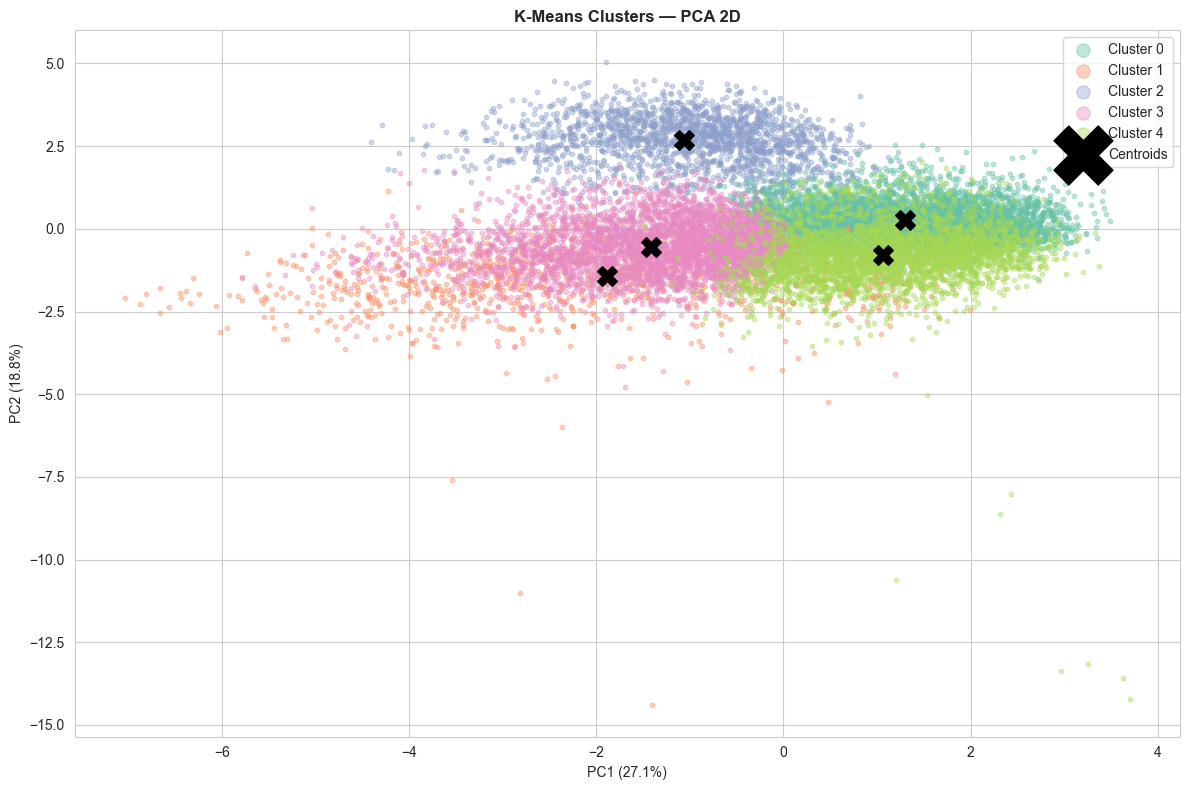

In [11]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

pidx = np.random.choice(len(X_pca), 15000, replace=False)
plt.figure(figsize=(12, 8))
for i in range(OPTIMAL_K):
    m = labels[pidx] == i
    plt.scatter(X_pca[pidx][m, 0], X_pca[pidx][m, 1],
                c=[palette[i]], label=f'Cluster {i}', alpha=0.4, s=10)

c2 = pca_2d.transform(kmeans.cluster_centers_)
plt.scatter(c2[:, 0], c2[:, 1], c='black', marker='X', s=200, zorder=5, label='Centroids')
plt.title('K-Means Clusters — PCA 2D', fontweight='bold')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(markerscale=3); plt.tight_layout(); plt.show()

In [12]:
cp = df.groupby('cluster')[FEATURES].mean().round(3)

def label_cluster(row):
    if row['energy'] > 0.75 and row['danceability'] > 0.65:   return 'Party / Upbeat'
    elif row['acousticness'] > 0.7 and row['energy'] < 0.45:  return 'Acoustic / Chill'
    elif row['instrumentalness'] > 0.5:                        return 'Instrumental'
    elif row['speechiness'] > 0.2:                             return 'Vocal / Spoken'
    else:                                                       return 'Balanced / Pop'

cp['label'] = cp.apply(label_cluster, axis=1)
cluster_map = cp['label'].to_dict()
df['cluster_label'] = df['cluster'].map(cluster_map)
print(cluster_map)

{0: 'Balanced / Pop', 1: 'Instrumental', 2: 'Vocal / Spoken', 3: 'Acoustic / Chill', 4: 'Balanced / Pop'}


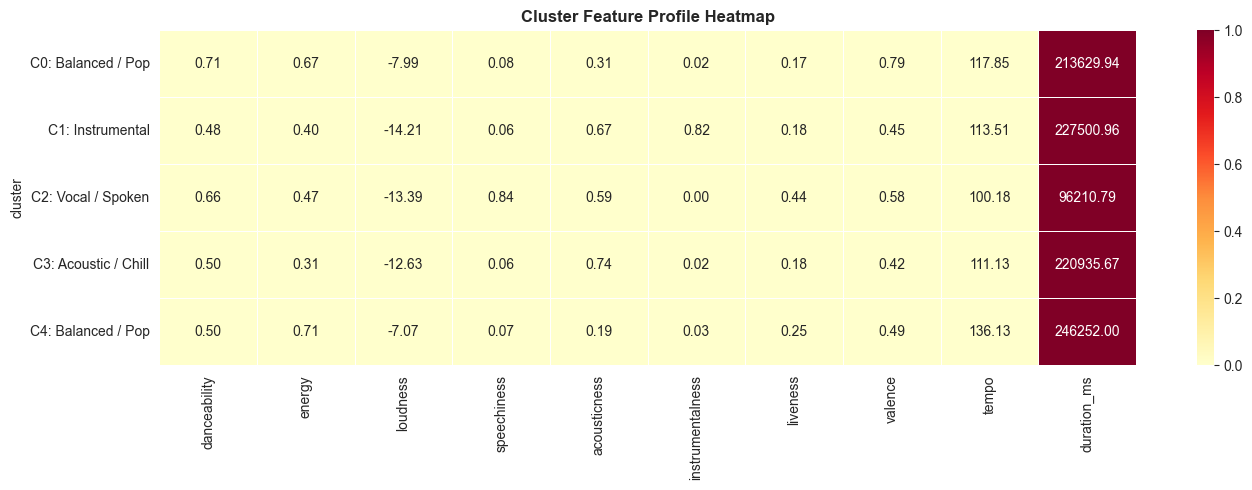

In [13]:
cp_num = cp.drop(columns=['label'])
mm = MinMaxScaler()
cp_norm = pd.DataFrame(mm.fit_transform(cp_num.T).T,
                       index=cp_num.index, columns=cp_num.columns)

plt.figure(figsize=(14, 5))
sns.heatmap(cp_norm, annot=cp_num, fmt='.2f', cmap='YlOrRd', linewidths=0.5,
            yticklabels=[f'C{i}: {cluster_map[i]}' for i in range(OPTIMAL_K)])
plt.title('Cluster Feature Profile Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

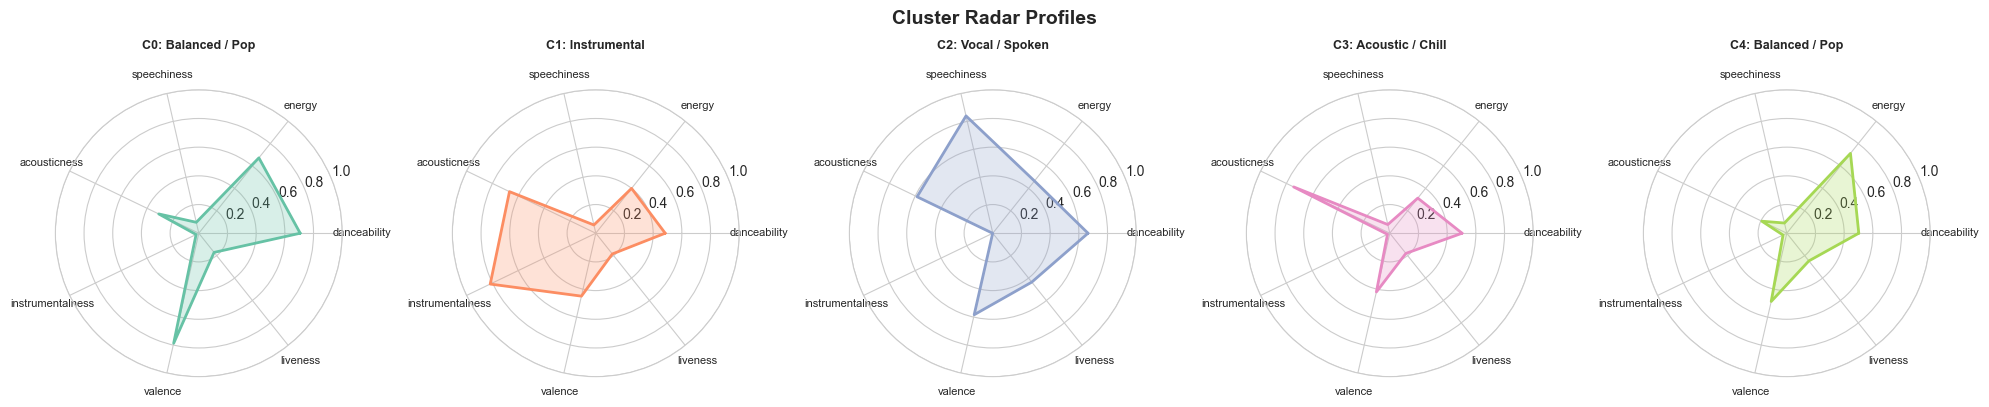

In [14]:
features_radar = ['danceability','energy','speechiness',
                  'acousticness','instrumentalness','valence','liveness']
N = len(features_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(20, 4), subplot_kw=dict(polar=True))
for i, ax in enumerate(axes):
    vals = cp_num.loc[i, features_radar].values.tolist() + [cp_num.loc[i, features_radar[0]]]
    ax.plot(angles, vals, color=palette[i], lw=2)
    ax.fill(angles, vals, color=palette[i], alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(features_radar, size=8)
    ax.set_title(f'C{i}: {cluster_map[i]}', size=9, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)
plt.suptitle('Cluster Radar Profiles', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

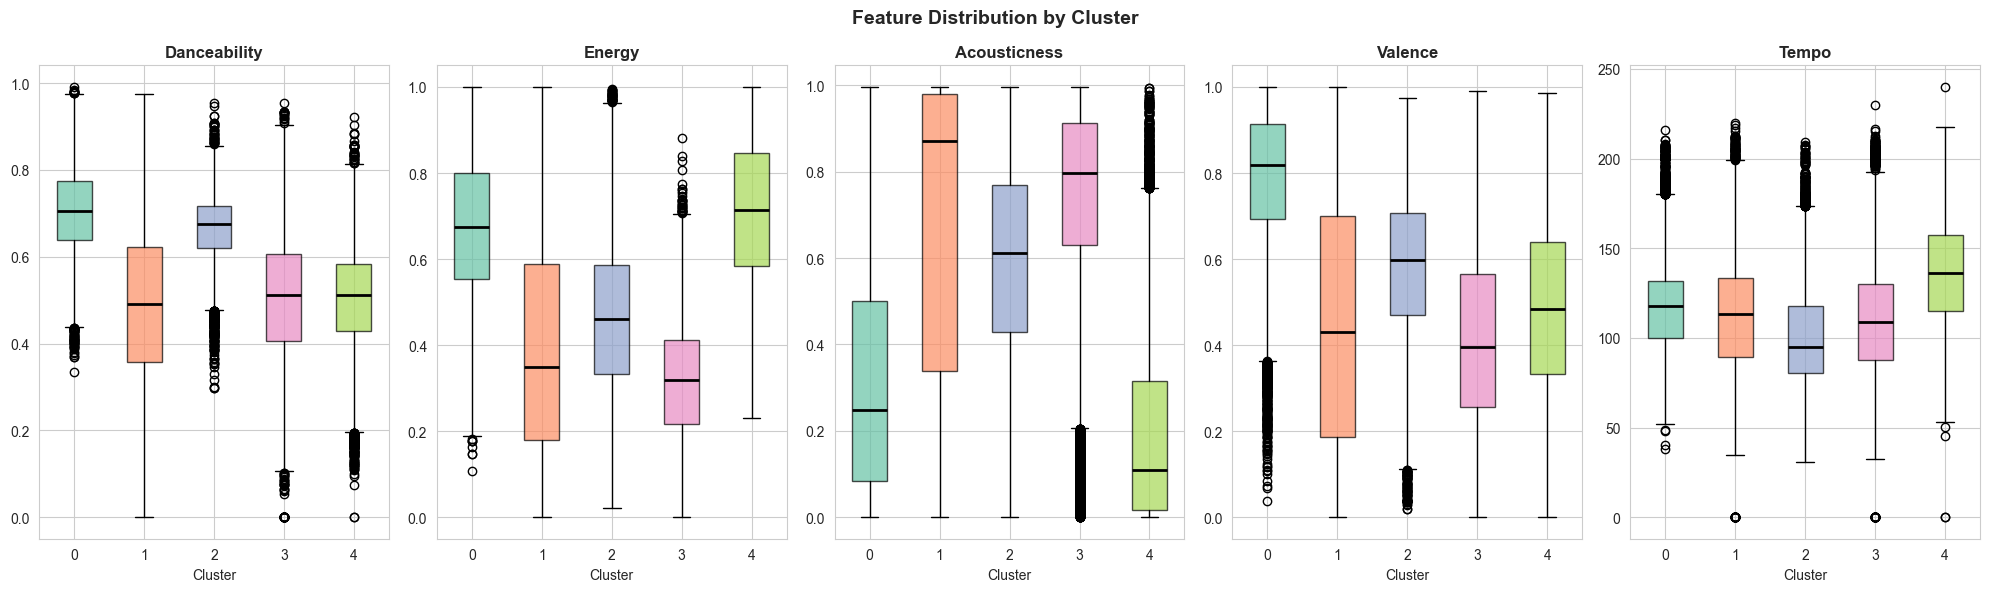

In [15]:
key_features = ['danceability','energy','acousticness','valence','tempo']
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for ax, feat in zip(axes, key_features):
    data = [df.loc[df['cluster'] == i, feat].values for i in range(OPTIMAL_K)]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(feat.capitalize(), fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_xticks(range(1, OPTIMAL_K+1)); ax.set_xticklabels(range(OPTIMAL_K))
plt.suptitle('Feature Distribution by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

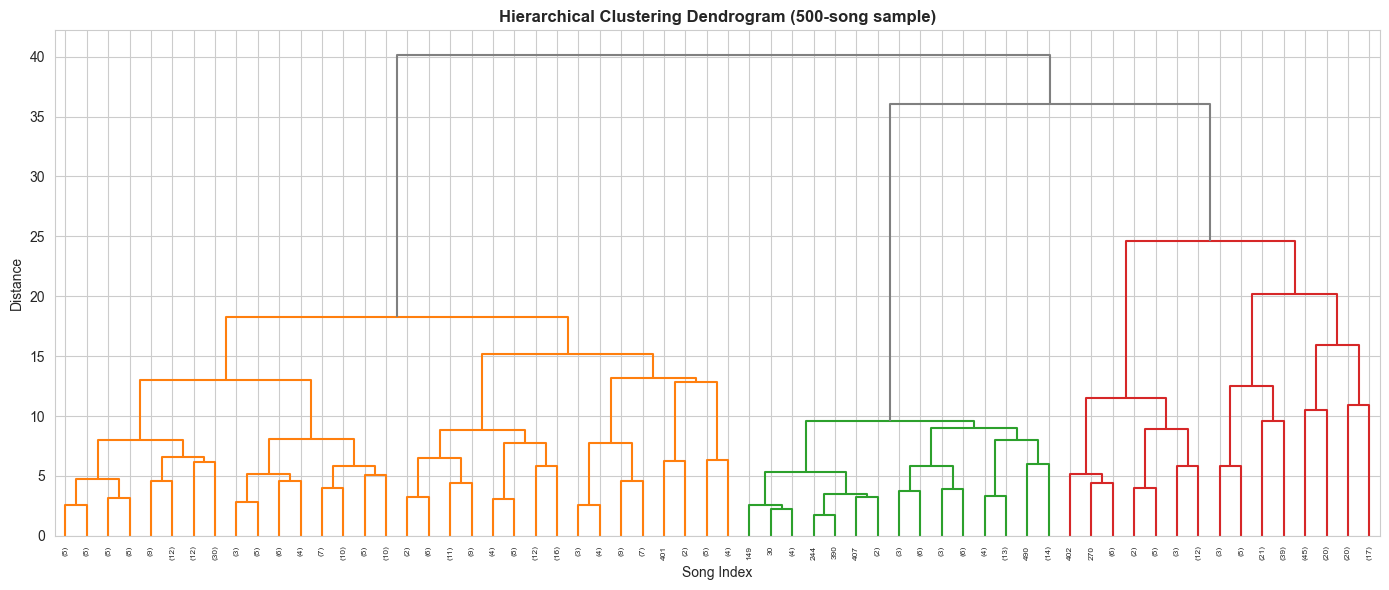

In [16]:
s500 = X_scaled[np.random.choice(len(X_scaled), 500, replace=False)]
linked = linkage(s500, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='level', p=5,
           color_threshold=0.7*max(linked[:, 2]),
           above_threshold_color='gray')
plt.title('Hierarchical Clustering Dendrogram (500-song sample)', fontweight='bold')
plt.xlabel('Song Index'); plt.ylabel('Distance')
plt.tight_layout(); plt.show()

In [17]:
eidx = np.random.choice(len(X_scaled), 20000, replace=False)
sil = silhouette_score(X_scaled[eidx], labels[eidx], random_state=42)
db  = davies_bouldin_score(X_scaled[eidx], labels[eidx])

print("=" * 45)
print("   📈 CLUSTER EVALUATION METRICS")
print("=" * 45)
print(f"  Silhouette Score     : {sil:.4f}  (↑ higher = better)")
print(f"  Davies-Bouldin Index : {db:.4f}  (↓ lower = better)")
print(f"  Inertia (SSE)        : {kmeans.inertia_:,.0f}")
print("=" * 45)

   📈 CLUSTER EVALUATION METRICS
  Silhouette Score     : 0.1855  (↑ higher = better)
  Davies-Bouldin Index : 1.6881  (↓ lower = better)
  Inertia (SSE)        : 548,595


In [18]:
df.to_csv('amazon_music_clustered.csv', index=False)

print("=" * 55)
print("     🎵 FINAL CLUSTER SUMMARY")
print("=" * 55)
for i in range(OPTIMAL_K):
    cnt = (labels == i).sum()
    print(f"  Cluster {i} | {cluster_map[i]:<20} | {cnt:>7,} songs ({cnt/len(labels)*100:.1f}%)")
print("=" * 55)
print("\n✅ Exported: amazon_music_clustered.csv")

# Sample songs per cluster
for i in range(OPTIMAL_K):
    print(f"\n🎵 Cluster {i} — {cluster_map[i]}")
    print(df[df['cluster']==i][['name_song','name_artists','genres']].head(3).to_string(index=False))

     🎵 FINAL CLUSTER SUMMARY
  Cluster 0 | Balanced / Pop       |  30,373 songs (31.7%)
  Cluster 1 | Instrumental         |   7,527 songs (7.9%)
  Cluster 2 | Vocal / Spoken       |  12,273 songs (12.8%)
  Cluster 3 | Acoustic / Chill     |  24,584 songs (25.7%)
  Cluster 4 | Balanced / Pop       |  21,080 songs (22.0%)

✅ Exported: amazon_music_clustered.csv

🎵 Cluster 0 — Balanced / Pop
                          name_song name_artists              genres
                          On M'suit  Mistinguett ['vintage chanson']
Je N'suis Pas Celle Que Vous Croyez    Perchicot ['vintage chanson']
                  La Noce À Rebecca    Perchicot ['vintage chanson']

🎵 Cluster 1 — Instrumental
                       name_song                   name_artists               genres
Veux Tu Que J'te Fasse Un Dessin                       Georgius  ['vintage chanson']
                  West End Blues Louis Armstrong & His Hot Five ['new orleans jazz']
                   Beau Koo Jack Louis Armstrong